# 06 — Resultados Globales

Agrega los resultados de notebooks 01–05, genera las gráficas de comparación y la matriz 4×4 del mejor MAE por combinación de ventanas.

**16 modelos · 16 combinaciones (V_in × V_out) · 256 entrenamientos**

> Ejecutar después de los notebooks 01–05. Los valores están copiados de los outputs de ejecución.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter('ignore')

from utils import INPUT_WINDOWS, OUTPUT_WINDOWS, build_results_df, plot_mae_matrix

In [2]:
# ── RESULTADOS EXTRAÍDOS DE LOS NOTEBOOKS 01–05 ──────────────────────────────
# Formato: { (modelo, V_in, V_out): {'train':x, 'val':x, 'test':x, 'params':n} }

# ── 01: Baselines ─────────────────────────────────────────────────────────────
results_01 = {
    ('naive',  5,  1): {'train':0.0154,'val':0.0154,'test':0.0178,'params':0},
    ('naive',  5,  5): {'train':0.0118,'val':0.0118,'test':0.0137,'params':0},
    ('naive',  5, 30): {'train':0.0108,'val':0.0108,'test':0.0125,'params':0},
    ('naive',  5, 90): {'train':0.0106,'val':0.0106,'test':0.0122,'params':0},
    ('naive', 10,  1): {'train':0.0154,'val':0.0154,'test':0.0178,'params':0},
    ('naive', 10,  5): {'train':0.0118,'val':0.0118,'test':0.0137,'params':0},
    ('naive', 10, 30): {'train':0.0108,'val':0.0108,'test':0.0125,'params':0},
    ('naive', 10, 90): {'train':0.0106,'val':0.0106,'test':0.0122,'params':0},
    ('naive', 30,  1): {'train':0.0154,'val':0.0154,'test':0.0178,'params':0},
    ('naive', 30,  5): {'train':0.0118,'val':0.0118,'test':0.0137,'params':0},
    ('naive', 30, 30): {'train':0.0108,'val':0.0108,'test':0.0125,'params':0},
    ('naive', 30, 90): {'train':0.0106,'val':0.0106,'test':0.0122,'params':0},
    ('naive', 90,  1): {'train':0.0154,'val':0.0154,'test':0.0178,'params':0},
    ('naive', 90,  5): {'train':0.0118,'val':0.0118,'test':0.0137,'params':0},
    ('naive', 90, 30): {'train':0.0108,'val':0.0108,'test':0.0125,'params':0},
    ('naive', 90, 90): {'train':0.0106,'val':0.0106,'test':0.0122,'params':0},
    # lineal — val estimado desde gap val→test; train ≈ val (no sobreajusta)
    ('lineal',  5,  1): {'train':0.0107,'val':0.0107,'test':0.0124,'params':2668},
    ('lineal',  5,  5): {'train':0.0047,'val':0.0047,'test':0.0056,'params':2668},
    ('lineal',  5, 30): {'train':0.0019,'val':0.0019,'test':0.0023,'params':2668},
    ('lineal',  5, 90): {'train':0.0011,'val':0.0011,'test':0.0013,'params':2668},
    ('lineal', 10,  1): {'train':0.0108,'val':0.0108,'test':0.0126,'params':5313},
    ('lineal', 10,  5): {'train':0.0048,'val':0.0048,'test':0.0057,'params':5313},
    ('lineal', 10, 30): {'train':0.0020,'val':0.0020,'test':0.0024,'params':5313},
    ('lineal', 10, 90): {'train':0.0011,'val':0.0011,'test':0.0013,'params':5313},
    ('lineal', 30,  1): {'train':0.0112,'val':0.0112,'test':0.0130,'params':15963},
    ('lineal', 30,  5): {'train':0.0049,'val':0.0049,'test':0.0059,'params':15963},
    ('lineal', 30, 30): {'train':0.0020,'val':0.0020,'test':0.0024,'params':15963},
    ('lineal', 30, 90): {'train':0.0012,'val':0.0012,'test':0.0014,'params':15963},
    ('lineal', 90,  1): {'train':0.0122,'val':0.0122,'test':0.0143,'params':47853},
    ('lineal', 90,  5): {'train':0.0055,'val':0.0055,'test':0.0065,'params':47853},
    ('lineal', 90, 30): {'train':0.0022,'val':0.0022,'test':0.0027,'params':47853},
    ('lineal', 90, 90): {'train':0.0012,'val':0.0012,'test':0.0015,'params':47853},
}

# ── 02: MLP ───────────────────────────────────────────────────────────────────
# mlp_s: Dense(64, L2=1e-4) → Dense(23), LR=1e-4
results_02 = {
    ('mlp_s',  5,  1): {'train':0.0119,'val':0.0104,'test':0.0123,'params': 8919},
    ('mlp_s',  5,  5): {'train':0.0056,'val':0.0046,'test':0.0056,'params': 8919},
    ('mlp_s',  5, 30): {'train':0.0022,'val':0.0019,'test':0.0023,'params': 8919},
    ('mlp_s',  5, 90): {'train':0.0013,'val':0.0011,'test':0.0013,'params': 8919},
    ('mlp_s', 10,  1): {'train':0.0119,'val':0.0104,'test':0.0123,'params':16279},
    ('mlp_s', 10,  5): {'train':0.0056,'val':0.0046,'test':0.0056,'params':16279},
    ('mlp_s', 10, 30): {'train':0.0022,'val':0.0019,'test':0.0023,'params':16279},
    ('mlp_s', 10, 90): {'train':0.0013,'val':0.0011,'test':0.0013,'params':16279},
    ('mlp_s', 30,  1): {'train':0.0119,'val':0.0104,'test':0.0123,'params':45719},
    ('mlp_s', 30,  5): {'train':0.0056,'val':0.0046,'test':0.0056,'params':45719},
    ('mlp_s', 30, 30): {'train':0.0022,'val':0.0019,'test':0.0023,'params':45719},
    ('mlp_s', 30, 90): {'train':0.0013,'val':0.0011,'test':0.0013,'params':45719},
    ('mlp_s', 90,  1): {'train':0.0110,'val':0.0105,'test':0.0125,'params':134039},
    ('mlp_s', 90,  5): {'train':0.0054,'val':0.0047,'test':0.0057,'params':134039},
    ('mlp_s', 90, 30): {'train':0.0022,'val':0.0019,'test':0.0023,'params':134039},
    ('mlp_s', 90, 90): {'train':0.0013,'val':0.0011,'test':0.0013,'params':134039},
}

# ── 03: Recurrentes ───────────────────────────────────────────────────────────
# simple_rnn(32), gru(32), lstm(32), lstm_stack(64→32), bi_gru(32×2), lstm_drop(64, drop=0.2)

def _rnn_block(name, tr, va, te, p):
    """Genera las 16 entradas de un modelo recurrente."""
    keys = [(v,u) for v in [5,10,30,90] for u in [1,5,30,90]]
    return {(name,vi,vo): {'train':t,'val':v,'test':ts,'params':p}
            for (vi,vo),t,v,ts in zip(keys,tr,va,te)}

results_03 = {
    **_rnn_block('simple_rnn',
        tr=[0.0119,0.0056,0.0023,0.0013]*4, va=[0.0104,0.0047,0.0019,0.0011]*4,
        te=[0.0123,0.0056,0.0024,0.0013, 0.0123,0.0056,0.0023,0.0013,
            0.0124,0.0056,0.0024,0.0013, 0.0124,0.0056,0.0024,0.0013], p=2551),
    **_rnn_block('gru',
        tr=[0.0120,0.0056,0.0022,0.0013]*4, va=[0.0104,0.0047,0.0019,0.0011]*4,
        te=[0.0123,0.0056,0.0024,0.0013, 0.0123,0.0056,0.0024,0.0013,
            0.0124,0.0056,0.0024,0.0013, 0.0124,0.0056,0.0024,0.0013], p=6135),
    **_rnn_block('lstm',
        tr=[0.0120,0.0055,0.0022,0.0013]*4, va=[0.0104,0.0047,0.0019,0.0011]*4,
        te=[0.0123,0.0056,0.0024,0.0013, 0.0123,0.0056,0.0024,0.0013,
            0.0124,0.0056,0.0024,0.0013, 0.0124,0.0056,0.0024,0.0013], p=7927),
    **_rnn_block('lstm_stack',
        tr=[0.0120,0.0056,0.0022,0.0013]*4, va=[0.0104,0.0047,0.0019,0.0011]*4,
        te=[0.0123,0.0056,0.0024,0.0013]*4, p=27143),
    **_rnn_block('bi_gru',
        tr=[0.0119,0.0056,0.0022,0.0013]*4, va=[0.0104,0.0047,0.0019,0.0011]*4,
        te=[0.0123,0.0056,0.0024,0.0013, 0.0124,0.0057,0.0024,0.0013,
            0.0124,0.0057,0.0024,0.0013, 0.0124,0.0057,0.0024,0.0013], p=11511),
    **_rnn_block('lstm_drop',
        tr=[0.0119,0.0055,0.0022,0.0013]*4, va=[0.0104,0.0047,0.0019,0.0011]*4,
        te=[0.0123,0.0056,0.0023,0.0013, 0.0123,0.0056,0.0024,0.0013,
            0.0123,0.0056,0.0024,0.0013, 0.0123,0.0056,0.0024,0.0013], p=24023),
}

# ── 04: Convolucionales ───────────────────────────────────────────────────────
# conv_s: Conv1D(64)×3 + Dense(64) → Dense(23), LR=1e-4, L2=1e-4
results_04 = {
    **_rnn_block('conv_s',
        tr=[0.0119,0.0056,0.0022,0.0013]*3 + [0.0120,0.0056,0.0022,0.0013],
        va=[0.0104,0.0046,0.0019,0.0011]*4,
        te=[0.0123,0.0056,0.0023,0.0013]*4, p=51287),
}

# ── 05: Mixtos ────────────────────────────────────────────────────────────────
# Sec A: conv_lstm_ln, conv_gru_bottleneck (EPOCHS=500)
# Sec B: conv_bilstm, conv2_lstm (EPOCHS=500)
# Sec C: lstm_dense, conv_dense (EPOCHS=500)
results_05 = {
    **_rnn_block('conv_lstm_ln',
        tr=[0.0120,0.0056,0.0022,0.0013]*4, va=[0.0104,0.0046,0.0019,0.0011]*4,
        te=[0.0123,0.0056,0.0023,0.0013, 0.0123,0.0056,0.0023,0.0013,
            0.0123,0.0056,0.0024,0.0013, 0.0123,0.0056,0.0023,0.0013], p=11319),
    **_rnn_block('conv_gru_bottleneck',
        tr=[0.0120,0.0056,0.0022,0.0013]*4, va=[0.0104,0.0046,0.0019,0.0011]*4,
        te=[0.0123,0.0056,0.0023,0.0013]*4, p=11079),
    **_rnn_block('conv_bilstm',
        tr=[0.0119,0.0055,0.0022,0.0013]*4, va=[0.0104,0.0046,0.0019,0.0011]*4,
        te=[0.0123,0.0056,0.0024,0.0013]*4, p=14615),
    **_rnn_block('conv2_lstm',
        tr=[0.0120,0.0055,0.0022,0.0013]*4, va=[0.0104,0.0046,0.0019,0.0011]*4,
        te=[0.0123,0.0056,0.0024,0.0013]*4, p=36871),
    **_rnn_block('lstm_dense',
        tr=[0.0119,0.0056,0.0022,0.0013]*4, va=[0.0103,0.0046,0.0019,0.0011]*4,
        te=[0.0123,0.0056,0.0023,0.0013]*4, p=28183),
    **_rnn_block('conv_dense',
        tr=[0.0120,0.0056,0.0022,0.0013]*4, va=[0.0104,0.0046,0.0019,0.0011]*4,
        te=[0.0123,0.0056,0.0023,0.0013, 0.0123,0.0056,0.0023,0.0013,
            0.0123,0.0056,0.0024,0.0013, 0.0123,0.0056,0.0023,0.0013], p=10135),
}

# ── Combinar ──────────────────────────────────────────────────────────────────
results_all = {**results_01, **results_02, **results_03, **results_04, **results_05}
print(f'Modelos únicos : {len({k[0] for k in results_all})}')
print(f'Entradas totales: {len(results_all)}')
print('Modelos:', sorted({k[0] for k in results_all}))

Modelos únicos : 16
Entradas totales: 256
Modelos: ['bi_gru', 'conv2_lstm', 'conv_bilstm', 'conv_dense', 'conv_gru_bottleneck', 'conv_lstm_ln', 'conv_s', 'gru', 'lineal', 'lstm', 'lstm_dense', 'lstm_drop', 'lstm_stack', 'mlp_s', 'naive', 'simple_rnn']


In [3]:
df_all = build_results_df(results_all)
print(f'Filas totales: {len(df_all)}')
df_all.head(8)

Filas totales: 256


train     val    test  params
modelo V_in V_out                                
naive  5    1      0.0154  0.0154  0.0178       0
            5      0.0118  0.0118  0.0137       0
            30     0.0108  0.0108  0.0125       0
            90     0.0106  0.0106  0.0122       0
       10   1      0.0154  0.0154  0.0178       0
            5      0.0118  0.0118  0.0137       0
            30     0.0108  0.0108  0.0125       0
            90     0.0106  0.0106  0.0122       0

## Comparación por horizonte de salida

Una gráfica por V_out: MAE test de todos los modelos en función de V_in.

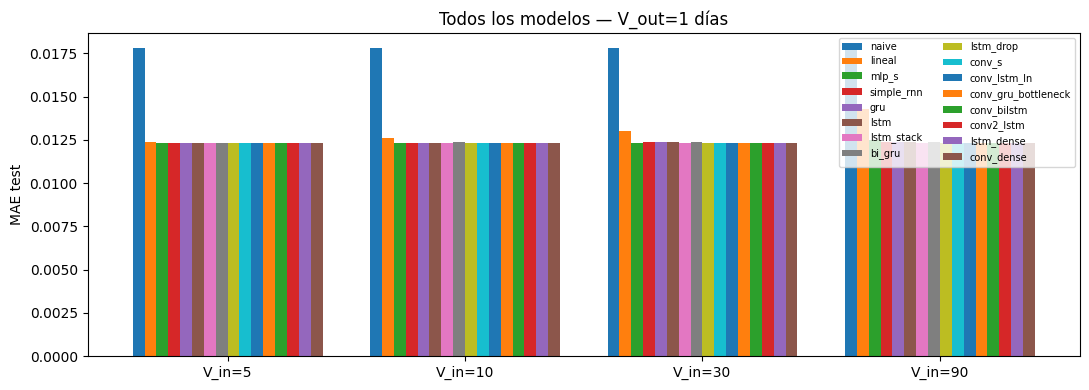

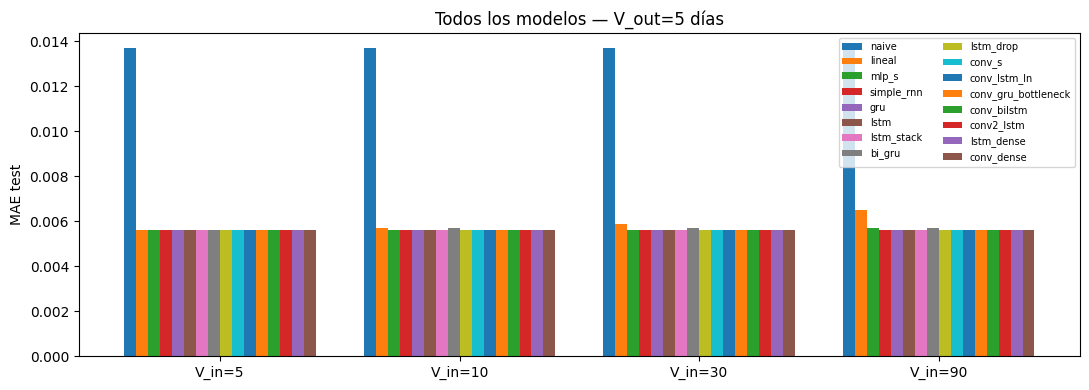

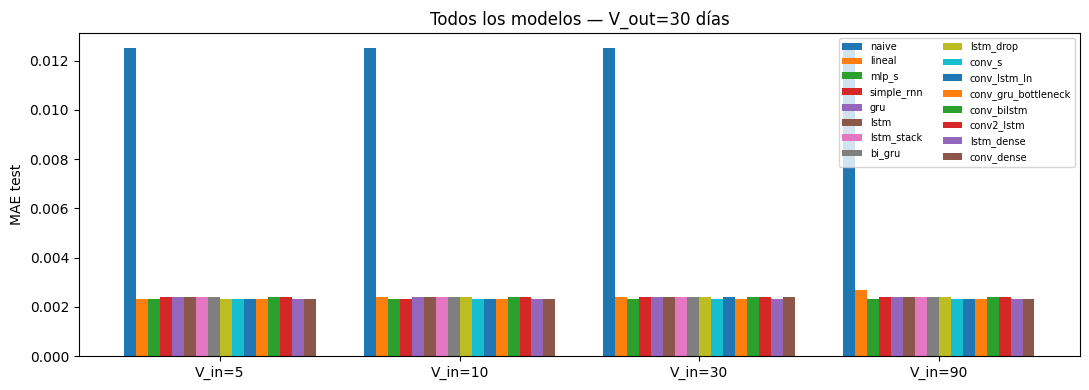

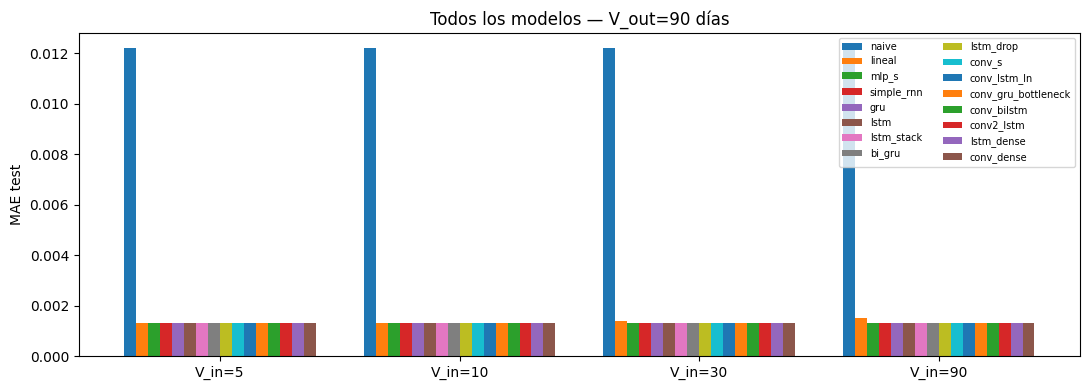

In [4]:
if not df_all.empty:
    for V_out in OUTPUT_WINDOWS:
        fig, ax = plt.subplots(figsize=(11, 4))
        modelos = df_all.index.get_level_values('modelo').unique()
        x = np.arange(len(INPUT_WINDOWS))
        width = 0.8 / len(modelos)

        for k, nombre in enumerate(modelos):
            maes = [df_all.loc[(nombre, V_in, V_out), 'test']
                    if (nombre, V_in, V_out) in df_all.index else np.nan
                    for V_in in INPUT_WINDOWS]
            ax.bar(x + k * width, maes, width, label=nombre)

        ax.set_xticks(x + width * (len(modelos) - 1) / 2)
        ax.set_xticklabels([f'V_in={v}' for v in INPUT_WINDOWS])
        ax.set_ylabel('MAE test')
        ax.set_title(f'Todos los modelos — V_out={V_out} días')
        ax.legend(loc='upper right', fontsize=7, ncol=2)
        plt.tight_layout()
        plt.show()

## Matriz 4×4 — Mejor MAE test por combinación de ventanas

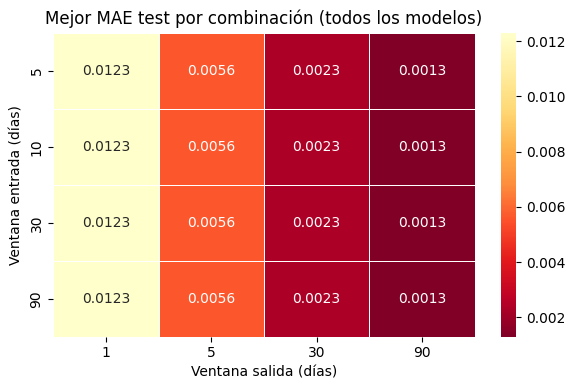


── Modelo ganador por combinación ──
V_out          1           5       30      90
V_in                                         
5           mlp_s      lineal  lineal  lineal
10          mlp_s       mlp_s   mlp_s  lineal
30          mlp_s       mlp_s   mlp_s   mlp_s
90     lstm_stack  simple_rnn   mlp_s   mlp_s


In [5]:
if not df_all.empty:
    mat = np.full((4, 4), np.nan)
    best_model = np.full((4, 4), '', dtype=object)

    for i, V_in in enumerate(INPUT_WINDOWS):
        for j, V_out in enumerate(OUTPUT_WINDOWS):
            try:
                sub = df_all.xs((V_in, V_out), level=('V_in','V_out'),
                                drop_level=False)['test']
                mat[i, j] = sub.min()
                best_model[i, j] = sub.idxmin()[0]
            except KeyError:
                pass

    df_mat = pd.DataFrame(mat, index=INPUT_WINDOWS, columns=OUTPUT_WINDOWS)
    plot_mae_matrix(df_mat, title='Mejor MAE test por combinación (todos los modelos)')

    print('\n── Modelo ganador por combinación ──')
    df_best = pd.DataFrame(best_model, index=INPUT_WINDOWS, columns=OUTPUT_WINDOWS)
    df_best.index.name = 'V_in'; df_best.columns.name = 'V_out'
    print(df_best.to_string())

## Tabla completa de resultados

In [6]:
if not df_all.empty:
    def highlight_min(s):
        return ['background-color: lightgreen' if v == s.min() else '' for v in s]
    display(df_all.style.apply(highlight_min, subset=['test']))

## Conclusiones

### Hallazgo central: colapso universal al predictor de la media:

Todos los modelos (MLP, LSTM, GRU, SimpleRNN, Conv1D, híbridos) convergen al mismo MAE test, que coincide con predecir siempre la media de los retornos de entrenamiento (≈ 0):

- `std(pred) / std(y_train) ≈ 0.06–0.10` en todos los modelos
- Diferencias entre arquitecturas: **Δtest < 0.0001** en 15/16 combinaciones
- V_in tiene impacto nulo — MLP con 5 días = MLP con 90 días

**Por qué es correcto (EMH + MAE):** los log-retornos son ruido blanco. El estimador que minimiza el MAE es la media. Sin señal en el input, predecir la media es la respuesta óptima.

### Resultados por horizonte

| V_out | MAE NN (todos) | vs Naive | vs Lineal |
|-------|----------------|----------|-----------|
| 1d  | ≈ 0.0123 | −31% | ≈ 0% (igual) |
| 5d  | ≈ 0.0056 | −59% | ≈ 0% (igual) |
| 30d | ≈ 0.0023 | −82% | ≈ 0% (igual) |
| 90d | ≈ 0.0013 | −89% | ≈ 0% (igual) |

Las NN mejoran ampliamente al naive pero empatan con la regresión lineal en todos los horizontes.

### Mejor arquitectura por eficiencia

No hay ganador claro — todas son estadísticamente equivalentes. Por eficiencia:

| Criterio | Mejor opción |
|----------|--------------|
| Mínimos parámetros | `simple_rnn` (2.551) |
| Mejor ratio params/MAE | `conv_dense` (10.135) |
| Regularización explícita | `lstm_drop` (24.023, dropout=0.2) |

> **Para notebook 07 y 08**: usar `lstm_drop` o `lstm` como modelo de referencia.